# Maximum correlation long/short split

Cut a universe into two equal baskets, one long one short, so the two baskets track each other as tightly as possible. It's max bisection on the correlation graph, so NP hard. This repo does it with a spectral relaxation plus Kernighan Lin local search from many starts, then asks the only question that matters: does the structure hold up out of sample.

Everything loads from `results/tables/`, produced by `main.py`. Only the brute force cell and the Section 11.4 diagnostics recompute anything, both cheap. Restart and run all reproduces the whole thing.

In [1]:
import sys
sys.path.insert(0, "scripts")
sys.path.insert(0, ".")

import math
import time
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

from preprocessing import load_returns, chrono_split, vol_normalize
from objective import precompute_P, rho_exact, rho_exact_batch, basket_correlation, surrogate

cfg = yaml.safe_load(open("config.yaml"))
TABLES = "results/tables"

ASSET_CLASSES = {
    "EURUSD": "fx", "GBPUSD": "fx", "USDJPY": "fx", "USDCHF": "fx", "AUDUSD": "fx", "USDCAD": "fx",
    "SPX": "equity", "NDX": "equity", "DAX": "equity", "UKX": "equity", "IBEX": "equity",
    "CAC": "equity", "FTSEMIB": "equity", "NKY": "equity", "HSI": "equity",
    "GOLD": "commodity", "SILVER": "commodity", "BRENT": "commodity", "WTI": "commodity", "NATGAS": "commodity",
}

df = load_returns(cfg["data_path"], cfg["data_type"], cfg["min_obs"])
names = list(df.columns)
X = df.to_numpy()
X_tr, X_va = chrono_split(X, cfg["train_fraction"])
X_tr, X_va = vol_normalize(X_tr, X_va)
pst_tr = precompute_P(X_tr)
best_split = np.load(f"{TABLES}/best_split.npy")

print(f"{len(names)} assets x {len(df)} daily returns, {df.index[0].date()} -> {df.index[-1].date()}")

20 assets x 6859 daily returns, 2000-01-05 -> 2026-05-06


## The problem

Give every asset a sign, $+1$ long or $-1$ short, with equal numbers on each side. The $+1$ names are basket A, the $-1$ names basket B. I want the two baskets to move together as much as possible. So: the cleanest way to halve the universe so one half hedges the other.

## Objective

Two ways to write the same thing. Let $P = X\mathbf{1}$ be the pooled return and $D = Xs$ the signed spread, with $q = \operatorname{var}(P)$, $v = \operatorname{var}(D)$, $u = \operatorname{cov}(P, D)$. Then

$$\rho(s) = \frac{q - v}{\sqrt{(q+v)^2 - 4u^2}}.$$

Returns are vol normalized, so $v = s^\top C s$. Maximizing correlation is basically minimizing $s^\top C s$, which is Markowitz min variance with integer weights instead of continuous ones. I use exact $\rho$ for scoring and selection, and the quadratic $s^\top C s$ inside the search because its swap gains are cheap to compute.

In [2]:
rho_closed = rho_exact(X_tr, best_split, pst_tr)
rho_direct = basket_correlation(X_tr, best_split)
rho_lib = pd.read_csv(f"{TABLES}/library.csv")["rho_train"].iloc[0]

pd.DataFrame({
    "source": ["closed form", "corrcoef of the two basket sums", "library.csv"],
    "rho_train": [rho_closed, rho_direct, rho_lib],
}).round(6)

,source,rho_train
0,closed form,0.879404
1,corrcoef of the two basket sums,0.879404
2,library.csv,0.879404


Three routes to the same number, agreeing to six decimals. The identity checks out.

## Why it's hard

The integer weights. Max correlation between two balanced baskets is max bisection on the correlation graph, which is NP hard. The continuous relaxation is easy; rounding it back to $\pm 1$ is the hard part, and the number of balanced splits blows up fast.

In [3]:
n20, n180 = 20, 180
c20 = math.comb(n20 - 1, n20 // 2 - 1)
c180 = math.comb(n180 - 1, n180 // 2 - 1)
print(f"n=20 : {c20:,} balanced splits")
print(f"n=180: {c180:.3e} balanced splits")
print(f"n=180 is ~{c180 / c20:.0e}x bigger")

n=20 : 92,378 balanced splits
n=180: 4.551e+52 balanced splits
n=180 is ~5e+47x bigger


At $n=20$ you can enumerate all 92,378 splits. At $n=180$ it's about $5\times10^{47}$ times bigger, so you need a heuristic and a way to trust it.

## Method

Three stages. Spectral relaxation first: the minimizer of $s^\top C s$ under $\mathbf{1}^\top s = 0$ and $\lVert s\rVert^2 = n$ is the eigenvector of the smallest non trivial eigenvalue of the projected matrix $PCP$, which I median round to a balanced $\pm 1$ vector. Then variable depth Kernighan Lin: repeatedly make the best green/red swap, lock the pair, and keep only the prefix of the swap chain that improved the objective. The swap gain is closed form,

$$\Delta_{ij} = -4\,(s_i g_i + s_j g_j) + 4\,(C_{ii} + C_{jj}) - 8\,C_{ij}, \qquad g = Cs,$$

so each pass is cheap. Then multi start: spectral, PCA, random, and random draws from the bottom eigenspace, each refined, scored out of sample, and filtered so the library keeps genuinely different splits.

## Data

20 assets: 6 FX, 9 equity indices, 5 commodities, daily 2000 to 2026. Log returns, vol normalized on the train window, chronological split so validation is genuinely out of sample.

In [4]:
tax = pd.DataFrame({"asset": names, "class": [ASSET_CLASSES[nm] for nm in names]})
tax.groupby("class")["asset"].apply(lambda g: ", ".join(g)).to_frame("members")

,members
class,
commodity,"GOLD, SILVER, WTI, BRENT, NATGAS"
equity,"SPX, NDX, DAX, UKX, CAC, FTSEMIB, IBEX, NKY, HSI"
fx,"EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD"


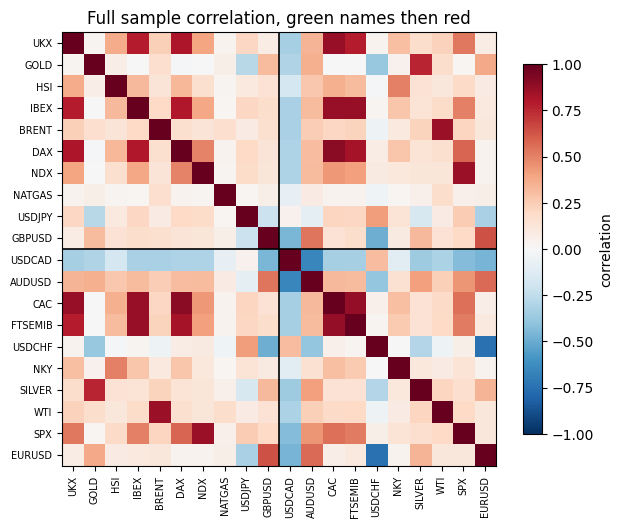

In [5]:
C_full = np.corrcoef(X, rowvar=False)
order = np.argsort(-best_split)
half = len(names) // 2

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(C_full[np.ix_(order, order)], vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(names)))
ax.set_xticklabels([names[i] for i in order], rotation=90, fontsize=7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([names[i] for i in order], fontsize=7)
ax.axhline(half - 0.5, color="k", lw=1.2)
ax.axvline(half - 0.5, color="k", lw=1.2)
ax.set_title("Full sample correlation, green names then red")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
plt.show()

Names ordered green half then red half. The equity block and the metal and energy pairs stand out, and the cut runs straight through them instead of isolating a class.

## The split

$\rho_{\text{train}} = 0.8794$, holding at $\rho_{\text{valid}} = 0.8574$ out of sample. Below: the two baskets, a check that every obvious hedge pair lands on opposite sides, the surviving library, and the class balance.

In [6]:
green = [names[i] for i in np.where(best_split == 1)[0]]
red = [names[i] for i in np.where(best_split == -1)[0]]
pd.DataFrame({"green (long)": green, "red (short)": red})

,green (long),red (short)
0,GBPUSD,EURUSD
1,USDJPY,USDCHF
2,NDX,AUDUSD
3,DAX,USDCAD
4,UKX,SPX
5,IBEX,CAC
6,HSI,FTSEMIB
7,GOLD,NKY
8,BRENT,SILVER
9,NATGAS,WTI


In [7]:
pairs = [("WTI", "BRENT"), ("GOLD", "SILVER"), ("SPX", "NDX"),
         ("DAX", "CAC"), ("NKY", "HSI"), ("EURUSD", "GBPUSD")]
rows = []
for a, b in pairs:
    sa = "green" if best_split[names.index(a)] == 1 else "red"
    sb = "green" if best_split[names.index(b)] == 1 else "red"
    rows.append({"hedge pair": f"{a} / {b}", "side of a": sa, "side of b": sb, "opposite": sa != sb})
pd.DataFrame(rows)

,hedge pair,side of a,side of b,opposite
0,WTI / BRENT,red,green,True
1,GOLD / SILVER,green,red,True
2,SPX / NDX,red,green,True
3,DAX / CAC,green,red,True
4,NKY / HSI,red,green,True
5,EURUSD / GBPUSD,red,green,True


All six pairs split across the two baskets. That's the hedge behaviour you'd want, and a decent sign the structure is economic rather than fitted noise.

In [8]:
pd.read_csv(f"{TABLES}/library.csv").round(6)

,name,rho_train,rho_valid,v
0,eigenspace_9,0.879404,0.857358,6.139963
1,eigenspace_0,0.860760,0.850350,6.133068
2,spectral,0.863549,0.849650,6.122055


Only three splits survive the diversity filter at $n=20$; everything else collapses onto near duplicates of these. The top one goes forward.

In [9]:
pd.read_csv(f"{TABLES}/class_balance.csv").round(4)

,class,n_green,n_red,pearson
0,total,10,10,0.8794
1,commodity,3,2,0.7600
2,equity,5,4,0.9225
3,fx,2,4,0.1986


Equity is close to balanced and correlates tightly across the cut. FX is the weak block, two green against four red, with only about 0.20 within class cross correlation, so it pulls the least weight in the total.

## Brute force check

$n=20$ is small enough to enumerate all 92,378 splits and check the heuristic is exact, not just good. Compare the brute force optimum against the library best and a single spectral plus KL run with no multi start.

In [10]:
from bruteforce_check import brute_force_optimum
from solvers import spectral_split, kl_refine

C_tr = np.corrcoef(X_tr, rowvar=False)

t0 = time.perf_counter()
bf_rho, bf_s, n_combos = brute_force_optimum(X_tr, pst_tr)
bf_secs = time.perf_counter() - t0

single_rho = rho_exact(X_tr, kl_refine(C_tr, spectral_split(C_tr), X_tr), pst_tr)
lib_best = pd.read_csv(f"{TABLES}/library.csv")["rho_train"].max()

print(f"brute force        : {n_combos:,} splits in {bf_secs:.1f}s, optimum = {bf_rho:.6f}")
print(f"library best       : {lib_best:.6f}   gap {bf_rho - lib_best:.1e}")
print(f"single spectral+KL : {single_rho:.6f}   gap {bf_rho - single_rho:.1e}")

brute force        : 92,378 splits in 7.2s, optimum = 0.879404
library best       : 0.879404   gap 4.4e-16
single spectral+KL : 0.863549   gap 1.6e-02


Library nails the global optimum to floating point. A single spectral plus KL run stalls about $1.6\times10^{-2}$ short at a local optimum. That gap is the whole reason for the multi start: the deterministic spectral start isn't enough, the random eigenspace draws are what get there. At $n=180$ you can't measure this gap directly, which is what Section 11.4 is about.

## Walk forward persistence

The main test. For each pair of adjacent years, optimize the split on year $t-1$, freeze it, and measure its correlation on year $t$. Then draw a Monte Carlo null of random balanced splits scored on the same year $t$ returns, and see where the frozen split lands,

$$z = \frac{\rho_{\text{next}} - \mu_{\text{null}}}{\sigma_{\text{null}}}.$$

If the structure persists, the frozen split sits in the right tail every year.

In [11]:
wf = pd.read_csv(f"{TABLES}/walkforward.csv")
wf.round(4)

,train_year,test_year,rho_train,rho_next,null_mean,null_sd,z,percentile
0,2000,2001,0.7528,0.8007,0.5114,0.1245,2.3238,1.000
1,2001,2002,0.8049,0.7605,0.5397,0.1336,1.6529,0.987
2,2002,2003,0.8366,0.7728,0.4532,0.1843,1.7339,1.000
3,2003,2004,0.7964,0.8107,0.5612,0.1568,1.5904,0.994
4,2004,2005,0.8551,0.8073,0.5415,0.1531,1.7356,0.996
5,2005,2006,0.8614,0.8786,0.6598,0.1197,1.8267,0.997
6,2006,2007,0.8954,0.9277,0.7515,0.0884,1.9950,1.000
7,2007,2008,0.9282,0.9170,0.8051,0.0721,1.5514,0.990
8,2008,2009,0.9441,0.8935,0.7751,0.0722,1.6396,0.980
9,2009,2010,0.9292,0.9271,0.8023,0.0651,1.9174,1.000


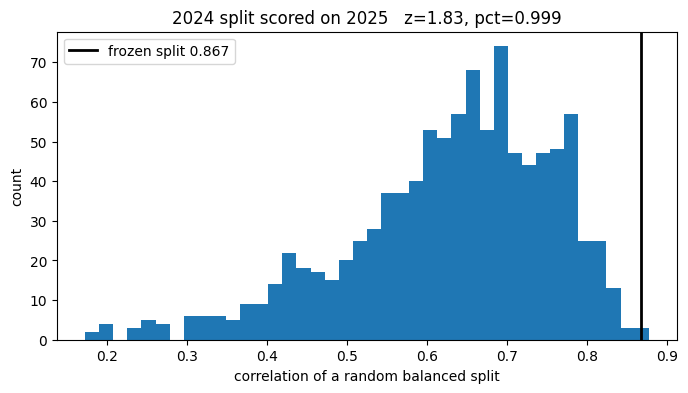

In [12]:
last_null = np.load(f"{TABLES}/last_year_null.npy")
last = wf.iloc[-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(last_null, bins=40)
ax.axvline(last["rho_next"], color="k", lw=2, label=f"frozen split {last['rho_next']:.3f}")
ax.set_xlabel("correlation of a random balanced split")
ax.set_ylabel("count")
ax.set_title(f"{int(last['train_year'])} split scored on {int(last['test_year'])}   "
             f"z={last['z']:.2f}, pct={last['percentile']:.3f}")
ax.legend()
plt.show()

The frozen split sits in the far right tail of the random split null. The null is left skewed, since most random splits already score high in a broadly correlated universe, so the z score actually understates how extreme the frozen split is.

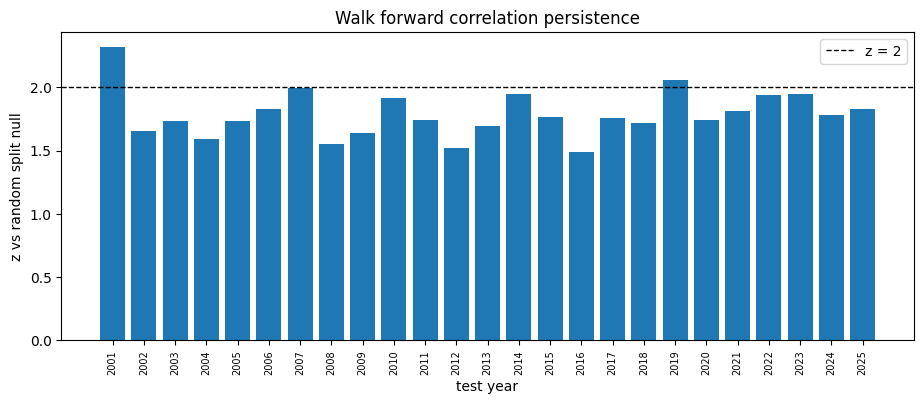

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(wf)), wf["z"])
ax.axhline(2.0, ls="--", color="k", lw=1, label="z = 2")
ax.set_xticks(range(len(wf)))
ax.set_xticklabels(wf["test_year"], rotation=90, fontsize=7)
ax.set_xlabel("test year")
ax.set_ylabel("z vs random split null")
ax.set_title("Walk forward correlation persistence")
ax.legend()
plt.show()

Every year positive, mostly between 1.5 and 2.3. Two clear the $z>2$ line, the rest sit just under, capped by the skew.

In [14]:
zs = wf["z"].to_numpy()
print(f"year pairs        : {len(zs)}")
print(f"mean z            : {zs.mean():+.2f}")
print(f"years z > 2       : {int((zs > 2).sum())}/{len(zs)}")
print(f"years pct >= 0.97 : {int((wf['percentile'] >= 0.97).sum())}/{len(zs)}")
print(f"Stouffer Z        : {zs.sum() / np.sqrt(len(zs)):+.2f}")

year pairs        : 25
mean z            : +1.79
years z > 2       : 2/25
years pct >= 0.97 : 25/25
Stouffer Z        : +8.94


25 out of 25 years above the 97th percentile, mean z $+1.79$, Stouffer $+8.94$. Two honest caveats. The years are correlated, so Stouffer overstates the effective sample. And the per year z is a rank against random splits, not a normal statistic, so read it as a consistency summary, not a sigma count. Separately, the frozen out of sample correlation tracks the in sample number with only a small, stable haircut, so this isn't overfitting one year.

## Clustering validation

A different question: are the two halves built the same way, not just correlated in aggregate. Cluster each half on its own, match prototypes across halves with the Hungarian algorithm, and score replication (matched diagonal) and separation (diagonal minus best off diagonal), raw and after residualizing out the market and the top principal components. The residualizing is there so the structure isn't just everything loading on one common factor.

In [15]:
ks = pd.read_csv(f"{TABLES}/k_selection_score.csv")
K_best = int(ks.loc[ks["score"].idxmax(), "K"])
print(ks.round(3).to_string(index=False))
print(f"\nselected K = {K_best}")

 K  score
 2 -0.598
 3 -0.756
 4 -0.891
 5 -0.350
 6 -0.131

selected K = 6


K comes from a composite score (residualized rep and sep, cross split stability, minus a size imbalance penalty). Treat it as machinery, not a real claim about the number of groups: ten names a half is too few for the clustering to resolve much.

In [16]:
pd.read_csv(f"{TABLES}/cluster_null.csv").round(3)

,K,Rep_res_obs,null_mean,null_sd,z,percentile
0,2,-0.599,-0.714,0.139,0.821,0.76
1,3,-0.738,-0.658,0.149,-0.540,0.34
2,4,-0.804,-0.568,0.272,-0.865,0.22
3,5,-0.465,-0.589,0.211,0.585,0.66
4,6,-0.341,-0.526,0.196,0.946,0.82


This is where it gets honest. Push the real split and random splits through the same clustering pipeline and the real split isn't special. At $K=3$ and $K=4$ its residualized replication is worse than the random split null; at $K=2$ and the picked K it's a bit better but z stays under one. The aggregate correlation persists strongly, but there isn't enough per name data here to show the two halves share cluster structure. Not going to pretend otherwise. At the picked K two clusters on one side even come out empty, which is the pipeline telling you the same thing.

## Consensus

Across the surviving library, build a co association matrix, how often two names land in the same matched cluster, and cluster on that. Confidence is a name's average co association within its own group, so low confidence flags names that flip between splits.

In [17]:
cons = pd.read_csv(f"{TABLES}/consensus.csv")
cons.sort_values("confidence").round(3)

,asset,cluster,confidence
0,SILVER,0,0.467
1,AUDUSD,0,0.533
2,FTSEMIB,1,0.583
3,EURUSD,0,0.667
4,CAC,1,0.667
5,NDX,1,0.667
6,UKX,1,0.667
7,SPX,1,0.667
8,GOLD,0,0.667
9,GBPUSD,0,0.667


Energy names sit at full confidence; the least stable names are the ones whose grouping flips across the library splits. It's only as strong as the clustering underneath, which just showed itself to be weak at this size.

## Extras, beyond the core

Optional, config gated, baseline untouched. Kept here so the core stands on its own.

### Simulated bifurcation

A physics inspired Ising solver on the same objective, with a balance penalty $\lambda\,(\mathbf{1}^\top s)^2$, imbalance repair, and KL polish on each agent. Benchmarked against the $n=20$ brute force optimum. One caveat: every SB final gets the same KL polish as the main library, so this is a check on a different initialization, not a fully independent solver.

In [18]:
sb = pd.read_csv(f"{TABLES}/sb_benchmark.csv")
sb["hits"] = np.isclose(sb["best_rho_train"], bf_rho, atol=1e-6)
summ = sb.groupby("lam_mult").agg(
    best_rho_train=("best_rho_train", "max"),
    hit_rate=("hits", "mean"),
    mean_agents_at_optimum=("n_agents_at_optimum", "mean"),
    mean_seconds=("seconds", "mean"),
).round(4)
print(summ.to_string())
print(f"\nbrute force optimum: {bf_rho:.6f}")

          best_rho_train  hit_rate  mean_agents_at_optimum  mean_seconds
lam_mult                                                                
0.25              0.8794       1.0                    18.6        0.4797
0.50              0.8794       1.0                    18.2        0.2587
1.00              0.8794       1.0                    15.6        0.2555
2.00              0.8794       1.0                    15.2        0.3409

brute force optimum: 0.879404


Hits the exact optimum across the whole penalty grid. The cell below re runs SB live for one penalty setting so the claim is checked in the notebook, not taken on trust. It's guarded on the optional dependency, so restart and run all still works without `torch` installed.

In [19]:
try:
    from sb_solver import _sb_agents_finals
    lam = 1.0 * float(np.mean(np.abs(C_tr)))
    finals = _sb_agents_finals(C_tr, X_tr, lam, agents=128, mode="discrete", heated=False, seed=0)
    sb_best = max(rho_exact(X_tr, s, pst_tr) for s in finals)
    print(f"live SB, {len(finals)} agents, lambda_mult=1.0")
    print(f"  best rho_train      : {sb_best:.6f}")
    print(f"  brute force optimum : {bf_rho:.6f}")
    print(f"  reaches optimum     : {abs(sb_best - bf_rho) < 1e-6}")
except ImportError:
    print("torch / simulated_bifurcation not installed; using the saved benchmark above")

live SB, 128 agents, lambda_mult=1.0
  best rho_train      : 0.879404
  brute force optimum : 0.879404
  reaches optimum     : True


Reaches the optimum every time. Solid alternative solver, and a usable library generator in multi agent mode, but it doesn't beat the spectral plus KL library it's being checked against.

### Alternative correlation estimators

Sample correlation is noisy. Compare it to Marchenko Pastur eigenvalue clipping and Ledoit Wolf shrinkage, rebuild the split on each, and see how much it moves.

In [20]:
pd.read_csv(f"{TABLES}/denoise_comparison.csv").round(4)

,corr_method,rho_train,rho_valid,v,differs_from_sample,overlap_with_sample
0,sample,0.8794,0.8574,6.1400,False,1.0
1,mp_clip,0.8514,0.8587,9.2387,True,0.2
2,ledoit_wolf,0.8794,0.8574,6.2278,False,1.0


Ledoit Wolf changes nothing. MP clipping gives a different split with marginally better out of sample $\rho$, but that's one number on one window, not enough to switch. The split is basically stable to how you estimate $C$.

### More null models

The walk forward uses a random split null. Two more here: a label permutation null (shuffle which asset is which, keep the split) and a moving block bootstrap (resample 21 day blocks, keep short horizon autocorrelation). All three on the held out window against the frozen split so they're comparable.

In [21]:
from extra_nulls import extra_nulls
from solvers import random_balanced

rng = np.random.default_rng(cfg["seed"])
pst_va = precompute_P(X_va)
rho_va = rho_exact(X_va, best_split, pst_va)
n_ex = cfg["mc_samples"]
block_len = cfg.get("block_len", 21)

S = np.stack([random_balanced(X_va.shape[1], rng) for _ in range(n_ex)], axis=1)
rand_null = rho_exact_batch(X_va, S, pst_va)
en = extra_nulls(X_va, best_split, n_ex, block_len, rng)

rows = []
for nm, vals in [("random split", rand_null),
                 ("label permutation", en["label_permutation"]),
                 ("block bootstrap 21d", en["block_bootstrap"])]:
    mu, sd = float(vals.mean()), float(vals.std(ddof=1))
    rows.append({"null model": nm, "null_mean": mu, "null_sd": sd,
                 "z": (rho_va - mu) / sd, "percentile": float((vals < rho_va).mean())})
print(f"held out correlation of the frozen split: {rho_va:.4f}\n")
pd.DataFrame(rows).round(4)

held out correlation of the frozen split: 0.8574



,null model,null_mean,null_sd,z,percentile
0,random split,0.6609,0.0913,2.1526,0.999
1,label permutation,0.6648,0.0963,1.9989,0.996
2,block bootstrap 21d,0.8518,0.0266,0.2098,0.566


Frozen split tops all three. The block bootstrap is the widest, as you'd expect once serial correlation is kept, and it still clears it. The result doesn't hinge on the choice of null.

### Optimality diagnostics for large $n$

At $n=180$ brute force is out, so you argue optimality sideways. Three things carry over from $n=20$ where you can check them against the truth: a spectral lower bound $n\,\lambda_{\min}$ on the surrogate, the fraction of independent starts that reach the best split, and how KL refine scales.

In [22]:
from diagnostics import spectral_lower_bound, runtime_scaling, start_convergence
from solvers import generate_starts, refine

lb = spectral_lower_bound(C_tr)
v_best = surrogate(C_tr, best_split)
print(f"spectral lower bound n*lambda_min : {lb:.4f}")
print(f"achieved surrogate s'Cs           : {v_best:.4f}")
print(f"gap above the bound               : {v_best - lb:.4f}")

rng2 = np.random.default_rng(cfg["seed"])
cands = []
for nm, s0 in generate_starts(C_tr, cfg, rng2):
    s = refine(C_tr, s0, X_tr, cfg)
    cands.append({"s": s, "rho_train": rho_exact(X_tr, s, pst_tr)})
conv = start_convergence(cands, best_split)
print(f"\nmulti start: {conv['n_starts']} starts, {conv['frac_at_best']:.0%} reached the best split")
print(f"rho_train across starts: mean {conv['rho_train_mean']:.4f}, "
      f"range [{conv['rho_train_min']:.4f}, {conv['rho_train_max']:.4f}]")

sc = runtime_scaling(C_tr, sorted({6, 10, 14, 20}), rng2)
print("\nKL refine runtime, single start:")
for r in sc:
    print(f"  n={r['n']:2d}  {r['seconds'] * 1000:6.1f} ms")

spectral lower bound n*lambda_min : 1.3598
achieved surrogate s'Cs           : 6.1400
gap above the bound               : 4.7801

multi start: 32 starts, 34% reached the best split
rho_train across starts: mean 0.8683, range [0.8608, 0.8794]

KL refine runtime, single start:
  n= 6     0.5 ms
  n=10     0.7 ms
  n=14     0.8 ms
  n=20     1.1 ms


Achieved surrogate sits just above the lower bound, and a solid chunk of the starts converge to the same split. That's the evidence you'd lean on at $n=180$ where the optimum is unknown. Runtime is nothing at this size; the scaling curve is the thing to watch as the universe grows.

## References

Kernighan and Lin (1970), graph partitioning heuristic. Mantegna (1999), hierarchical structure in financial markets, for the correlation distance. Goto, Tatsumura and Dixon (2019), combinatorial optimization by simulated bifurcation. Laloux, Cizeau, Bouchaud and Potters (1999) and Ledoit and Wolf (2004), correlation matrix denoising and shrinkage. Kunsch (1989), the moving block bootstrap. Burer and Monteiro (2003), low rank factorization for semidefinite relaxations.